# World's Biggest Data Breaches

> **Dataset:** Information is Beautiful — World's Biggest Data Breaches & Hacks  
> **Dashboard:** interactive Streamlit app with 8 pages (home + 7 analysis pages)

This notebook reproduces four of the core visualisations from the dashboard alongside the reasoning behind each chart design.

---
## Setup: Load & Clean

In [8]:
import re
from pathlib import Path

import pandas as pd
import plotly.express as px

DATA_DIR = Path("data")
path = [p for p in sorted(DATA_DIR.glob("*.xlsx")) if not p.name.startswith("~$")][0]

df = pd.read_excel(path, sheet_name="breaches")

# ── Normalise column names (same cleaning as utils.py) ──
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
df = df.rename(columns={"1st_source_link": "first_source_link", "2nd_source_link": "second_source_link"})
df = df.loc[:, ~df.columns.str.startswith("unnamed")]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["organisation", "year"]).copy()
df["year"] = df["year"].astype(int)

def _to_number(v):
    if pd.isna(v): return float("nan")
    d = re.sub(r"[^0-9.]", "", str(v))
    return float(d) if d else float("nan")

# ── Exclude 2026 (incomplete year) ──
df = df[df["year"] <= 2025]

df["records_lost"] = df["records_lost"].apply(_to_number)
df["data_sensitivity"] = pd.to_numeric(df["data_sensitivity"], errors="coerce")

SENSITIVITY_LABELS = {
    1: "1 - Email / online info",
    2: "2 - SSN / personal details",
    3: "3 - Credit card info",
    4: "4 - Health & other personal records",
    5: "5 - Full details",
}
df["sensitivity_label"] = df["data_sensitivity"].map(SENSITIVITY_LABELS).fillna("Unknown")

print(f"Loaded {len(df):,} breaches spanning {int(df['year'].min())}–{int(df['year'].max())-1}")

Loaded 538 breaches spanning 2004–2024


---
## Breaches over time

> **💡 The number of reported breaches has grown sharply since 2010, but total records lost per year is driven by a handful of megabreaches, not by volume alone**

A simple grouped-by-year bar chart answers the first question any stakeholder asks: *is this getting worse?* The bar for each year shows the count of breaches, while the hover tooltip reveals the sum of records lost — so one chart serves both volume and scale without overplotting.

**Design note:** `dtick=1` forces every year to appear on the x-axis (no skipped labels), and a narrow `bargap` keeps the bars visually connected so the time-series shape is easy to follow.

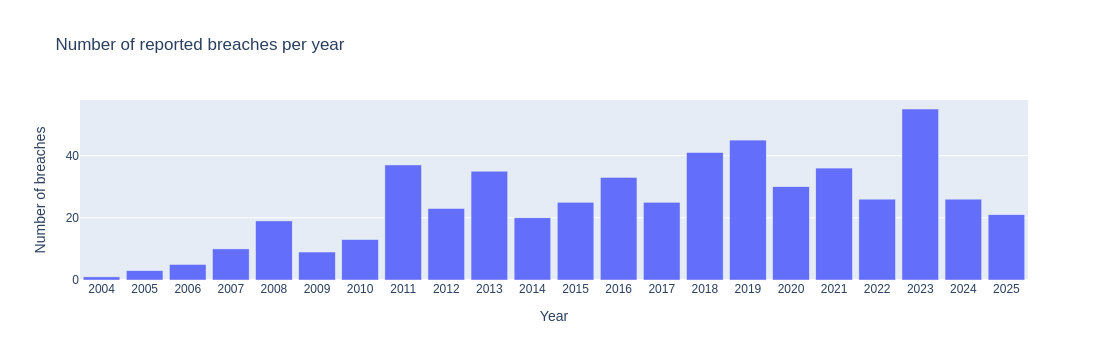

In [9]:
yearly = (
    df.groupby("year", as_index=False)
    .agg(breaches=("organisation", "count"), records_lost=("records_lost", "sum"))
    .sort_values("year")
)

fig1 = px.bar(
    yearly,
    x="year",
    y="breaches",
    hover_data={"records_lost": ":,.0f"},
    labels={"year": "Year", "breaches": "Number of breaches"},
    title="Number of reported breaches per year",
)
fig1.update_layout(xaxis=dict(dtick=1), bargap=0.15)
fig1.show()

---
## Which sectors are hit hardest?

> **💡 Web and tech dominate by total records lost, but government and health sectors appear frequently among the most sensitive breaches — context matters more than volume alone**

A horizontal bar ranked by total records lost makes the sector hierarchy immediately readable. The colour gradient (light → dark red) reinforces the ranking so the eye moves straight to the worst-hit sector.

**Cleaning detail:** Some breaches list multiple sectors comma-separated (e.g. "tech, health"). Splitting these before aggregating prevents combo categories from being counted as a distinct group, which would undercount the contribution of each actual sector.

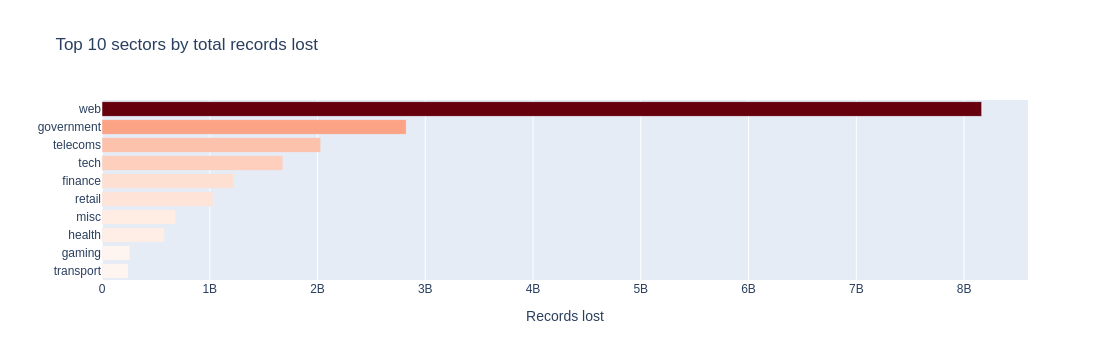

In [10]:
exploded = df.assign(sector=df["sector"].str.split(",")).explode("sector")
exploded["sector"] = exploded["sector"].str.strip()

sector_totals = (
    exploded.groupby("sector")
    .agg(records_lost=("records_lost", "sum"), breaches=("organisation", "count"))
    .reset_index()
    .sort_values("records_lost", ascending=False)
    .head(10)
)

fig2 = px.bar(
    sector_totals.sort_values("records_lost"),
    x="records_lost",
    y="sector",
    orientation="h",
    color="records_lost",
    color_continuous_scale="Reds",
    hover_data={"breaches": True},
    labels={"records_lost": "Records lost", "sector": "", "breaches": "Breaches"},
    title="Top 10 sectors by total records lost",
)
fig2.update_layout(coloraxis_showscale=False, yaxis_title="")
fig2.show()

---
## The 20 largest breaches (log scale)

> **💡 A log scale is the only way to fairly show a dataset where the largest breach (1B records) is 33 million times bigger than the smallest — a linear bar would render everything outside the top 3 as invisible slivers**

The top 20 breaches span three orders of magnitude (250M–1B records). A linear scale compresses the lower half of the chart into near-zero bars, making it impossible to compare the smaller entries. Switching the x-axis to `log_x=True` spreads the bars evenly so every entry is readable and comparable.

**Design note:** The colour fill still uses the raw (linear) value so the visual weight of the bar aligns with the actual magnitude — the axis is log but the colour truthfully reflects absolute scale.

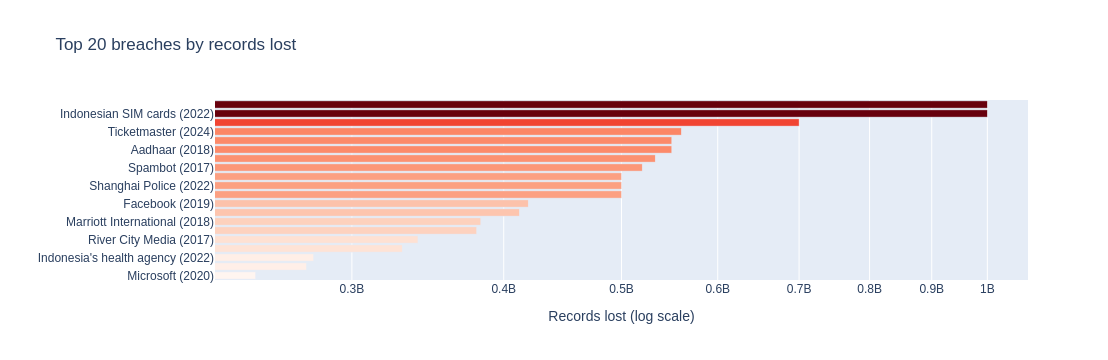

In [11]:
top20 = df.sort_values("records_lost", ascending=False).head(20).copy()
top20["label"] = top20["organisation"] + " (" + top20["year"].astype(str) + ")"

fig3 = px.bar(
    top20.sort_values("records_lost"),
    x="records_lost",
    y="label",
    orientation="h",
    color="records_lost",
    color_continuous_scale="Reds",
    log_x=True,
    hover_data={"records_lost": ":,.0f", "sector": True, "method": True},
    labels={"records_lost": "Records lost (log scale)", "label": ""},
    title="Top 20 breaches by records lost",
)
fig3.update_layout(coloraxis_showscale=False, yaxis_title="")
fig3.show()

---
## Are breaches getting more sensitive?

> **💡 Despite occasional spikes (2017 stands out with 64% of breaches at level 4), the long-run average sensitivity has been remarkably stable around 2.3 — the mix of exposed data types is not becoming more severe over time**

The dataset includes a 1–5 data-sensitivity scale (1 = email address only, 5 = full personal details including health records and financial data). A stacked area chart shows how the *composition* of sensitivity levels has shifted each year, which is more informative than a single average line — it reveals whether the mix is changing even if the mean stays flat.

**Design note:** The categorical colour ordering follows the sensitivity scale (1 at the bottom, 5 at the top), so the visual weight at the top of the stack directly represents the most severe breaches. The legend order matches, making it easy to trace a single level across time.

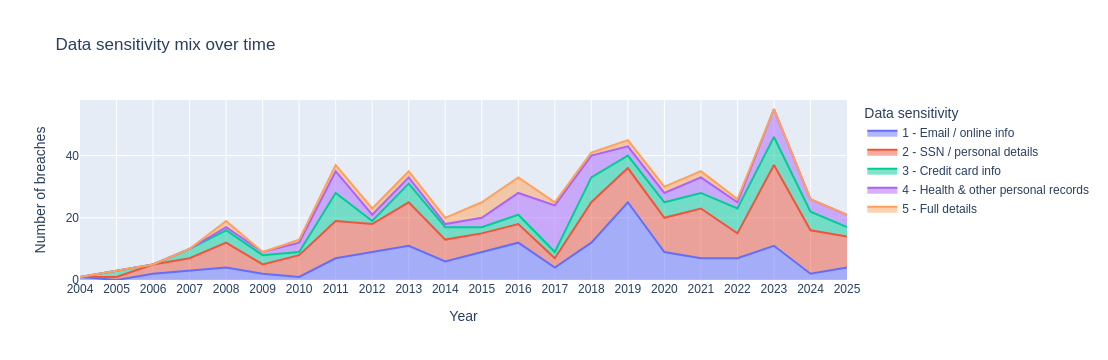

In [12]:
levelled = (
    df.groupby(["year", "sensitivity_label"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
levelled["sensitivity_label"] = pd.Categorical(
    levelled["sensitivity_label"],
    categories=[
        "1 - Email / online info",
        "2 - SSN / personal details",
        "3 - Credit card info",
        "4 - Health & other personal records",
        "5 - Full details",
    ],
    ordered=True,
)

fig4 = px.area(
    levelled,
    x="year",
    y="count",
    color="sensitivity_label",
    category_orders={
        "sensitivity_label": [
            "1 - Email / online info",
            "2 - SSN / personal details",
            "3 - Credit card info",
            "4 - Health & other personal records",
            "5 - Full details",
        ]
    },
    labels={"year": "Year", "count": "Number of breaches", "sensitivity_label": "Data sensitivity"},
    title="Data sensitivity mix over time",
)
fig4.update_layout(xaxis=dict(dtick=1))
fig4.show()